# Äquivalenzvergleich: Zeitexpandierter MILP-Solver vs. Dijkstra-Router

## Hintergrund

**Einzelne Sendung:** Da für eine einzelne Sendung das Problem der optimalen Routenwahl ein klassisches Kürzeste-Weg-Problem auf dem zeitexpandierten Graphen darstellt, müssen sowohl der MILP-Solver als auch der Dijkstra-Router exakt dasselbe Ergebnis liefern.

---

## 1. Setup und Imports

In [2]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights
from freight_routing.model import TimeExpandedFreightRoutingModel, TimeExpandedNetwork
from heuristics.dijkstra_router import DijkstraRouter
from freight_routing.visualization import create_network_map

## 2. Laden des Netzwerks

In [3]:
network_path = PROJECT_ROOT / "dataset/large_network.json"
print(f"Loading network from {network_path}...")
network_data = NetworkDataLoader.from_json(network_path)
network_data.summary()

Loading network from /home/benedikt/Projects/Sustainable_Freight_Mode_Choice/dataset/large_network.json...
Summary NetworkData:
hubs=870
arcs=36272
modes=4


## 3. Definition einer einzelnen Sendung für den ersten Test

In [4]:
shipment_1 = Shipment(
    id="user_shipment_1",
    start_hub="ALG_185",
    end_hub="ORA_186",
    start_time=0,
    deadline=2880,  # 2 Tage Horizont
    max_price=1_000_000.0,
    max_emissions=None,
    weight=2.0,
)

## 4. Basis-Äquivalenztest (Kostenminimierung)

In [5]:
weights_cost = ObjectiveWeights(cost=1.0, emissions=0.0, time=0.0)

# MILP
network_1 = TimeExpandedNetwork.build(
    network_data, planning_days=2, shipments=[shipment_1]
)
milp_model = TimeExpandedFreightRoutingModel(objective_weights=weights_cost)
milp_res = milp_model.solve(network_1)

# Dijkstra
dijkstra_router = DijkstraRouter(objective_weights=weights_cost)
dijkstra_res = dijkstra_router.solve(network_1)

print("--- Basis-Kostenoptimierung ---")
print(
    f"MILP Cost: {milp_res.total_cost:.2f} EUR | Dijkstra Cost: {dijkstra_res.total_cost:.2f} EUR"
)
milp_route = milp_res.shipment_routes[shipment_1.id]
dijkstra_route = dijkstra_res.shipment_routes[shipment_1.id]
milp_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in milp_route)
dijkstra_path = " -> ".join(
    f"{arc.from_node.hub_id}({arc.mode})" for arc in dijkstra_route
)
print(f"Pfade identisch: {milp_path == dijkstra_path}")

KeyboardInterrupt: 

## 5. Äquivalenztest mit unterschiedlichen Zielfunktions-Gewichten

1. **Reine Kostenoptimierung**
2. **Reine Emissionsoptimierung**
3. **Reine Zeitoptimierung**
4. **Ausgewogene Optimierung**

**Hinweis zu Einzelszenarien:** Bei reinen Einzelszenarien (z. B. nur Emissions- oder Zeitoptimierung) kann es theoretisch mehrere mathematisch gleichwertige Pfade geben. Da z.B. das Warten an Hubs 0 CO2-Emissionen verursachen kann, ist jeder Abfahrtszeitpunkt für die Emissionen gleichermaßen optimal. Dijkstra wählt den frühesten Start, während der MILP-Solver einen beliebigen gleichwertigen Pfad wählt.

In [ ]:
scenarios = [
    ("Reine Kostenoptimierung", ObjectiveWeights(cost=1.0, emissions=0.0, time=0.0)),
    ("Reine Emissionsoptimierung", ObjectiveWeights(cost=0.0, emissions=1.0, time=0.0)),
    ("Reine Zeitoptimierung", ObjectiveWeights(cost=0.0, emissions=0.0, time=1.0)),
    ("Ausgewogene Optimierung", ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)),
]

for name, scenario_weights in scenarios:
    print(f"\n=== Szenario: {name} ===")

    # MILP
    net = TimeExpandedNetwork.build(
        network_data, planning_days=2, shipments=[shipment_1]
    )
    m_model = TimeExpandedFreightRoutingModel(objective_weights=scenario_weights)
    m_res = m_model.solve(net)

    # Dijkstra
    d_router = DijkstraRouter(objective_weights=scenario_weights)
    d_res = d_router.solve(net)

    if m_res.is_optimal and d_res.is_optimal:
        m_route = m_res.shipment_routes[shipment_1.id]
        d_route = d_res.shipment_routes[shipment_1.id]
        m_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in m_route)
        d_path = " -> ".join(f"{arc.from_node.hub_id}({arc.mode})" for arc in d_route)

        cost_diff = abs(m_res.total_cost - d_res.total_cost)
        time_diff = abs(m_res.total_time - d_res.total_time)
        emissions_diff = abs(m_res.total_emissions - d_res.total_emissions)
        obj_diff = (
            abs(m_res.objective_value - d_res.objective_value)
            if (m_res.objective_value is not None and d_res.objective_value is not None)
            else 0.0
        )

        print(
            f"  Kosten: MILP={m_res.total_cost:.2f} EUR | Dijkstra={d_res.total_cost:.2f} EUR"
        )
        print(
            f"  CO2:    MILP={m_res.total_emissions:.2f} kg  | Dijkstra={d_res.total_emissions:.2f} kg"
        )
        print(
            f"  Dauer:  MILP={m_res.total_time:.2f} min | Dijkstra={d_res.total_time:.2f} min"
        )
        print(f"  Pfade identisch: {m_path == d_path}")

        if "Kosten" in name:
            assert cost_diff < 1e-3, f"Kosten weichen ab: {cost_diff}"
        elif "Emission" in name:
            assert emissions_diff < 1e-3, f"Emissionen weichen ab: {emissions_diff}"
        elif "Zeit" in name:
            assert time_diff < 1e-3, f"Dauer weicht ab: {time_diff}"
        else:
            assert obj_diff < 1e-3, f"Zielfunktionswert weicht ab: {obj_diff}"

        print(f"  [ERFOLG] Äquivalenz verifiziert!")
    else:
        print("  [FEHLER] Einer der Algorithmen fand keine Lösung.")


=== Szenario: Reine Kostenoptimierung ===
  Kosten: MILP=1260.80 EUR | Dijkstra=1260.80 EUR
  CO2:    MILP=134.28 kg  | Dijkstra=134.28 kg
  Dauer:  MILP=2498.00 min | Dijkstra=2498.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Reine Emissionsoptimierung ===
  Kosten: MILP=1260.80 EUR | Dijkstra=1260.80 EUR
  CO2:    MILP=134.28 kg  | Dijkstra=134.28 kg
  Dauer:  MILP=2498.00 min | Dijkstra=2498.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Reine Zeitoptimierung ===
  Kosten: MILP=1727.49 EUR | Dijkstra=1727.49 EUR
  CO2:    MILP=202.96 kg  | Dijkstra=202.96 kg
  Dauer:  MILP=484.00 min | Dijkstra=484.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!

=== Szenario: Ausgewogene Optimierung ===
  Kosten: MILP=1727.49 EUR | Dijkstra=1727.49 EUR
  CO2:    MILP=202.96 kg  | Dijkstra=202.96 kg
  Dauer:  MILP=484.00 min | Dijkstra=484.00 min
  Pfade identisch: True
  [ERFOLG] Äquivalenz verifiziert!


## 6. Vergleich für mehrere Sendungen mit Konsolidierung

In [6]:
# Definition der Sendungen
from freight_routing.data_models import Shipment, ObjectiveWeights, ArcType

shipment_m1 = Shipment(
    id="shipment_m1",
    start_hub="ALG_185",
    end_hub="ANT_1109",
    start_time=0,
    deadline=2880,
    max_price=1000000.0,
    max_emissions=None,
    weight=15.0,
)
shipment_m2 = Shipment(
    id="shipment_m2",
    start_hub="ALG_185",
    end_hub="GEN_1110",
    start_time=0,
    deadline=2880,
    max_price=1000000.0,
    max_emissions=None,
    weight=25.0,
)
multi_shipments = [shipment_m1, shipment_m2]
weights_multi = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)


def format_route(route) -> str:
    segments = []
    for arc in route:
        if arc.arc_type == ArcType.TRANSPORT:
            segments.append(
                f"{arc.from_node.hub_id} -> {arc.to_node.hub_id} ({arc.mode})"
            )
        elif arc.arc_type == ArcType.WAITING:
            segments.append(
                f"Wait@{arc.from_node.hub_id}({arc.mode}, {arc.duration_min}min)"
            )
        elif arc.arc_type == ArcType.TRANSFER:
            segments.append(
                f"Transfer@{arc.from_node.hub_id}({arc.from_node.mode} -> {arc.to_node.mode})"
            )
    return " | ".join(segments)


print("=== 1. MILP-Solver für mehrere Sendungen ===")
net_multi = TimeExpandedNetwork.build(
    network_data, planning_days=2, shipments=multi_shipments
)
milp_multi_model = TimeExpandedFreightRoutingModel(objective_weights=weights_multi)
res_milp_multi = milp_multi_model.solve(net_multi)

print(f"Status: {res_milp_multi.status}")
print(f"Kosten: {res_milp_multi.total_cost:.2f} EUR")
print(f"CO2:    {res_milp_multi.total_emissions:.2f} kg")
print(f"Kombinierter Zielfunktionswert: {res_milp_multi.objective_value:.6f}")
print(f"Konsolidiert: {res_milp_multi.is_consolidated}")
print("Routen:")
for s_id, route in res_milp_multi.shipment_routes.items():
    print(f"  {s_id}: {format_route(route)}")

print("\n=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===")
dijkstra_multi_router = DijkstraRouter(objective_weights=weights_multi)
res_heur_multi = dijkstra_multi_router.solve_multiple(net_multi)
res_opt_multi = dijkstra_multi_router.optimize_multiple(
    res_heur_multi,
    network=net_multi,
    iterations=20,
    ruin_fraction=0.5,
    seed=42,
)

print(f"Status (Greedy): {res_heur_multi.status}")
print(f"Kosten (Greedy): {res_heur_multi.total_cost:.2f} EUR")
print(f"Status (Optimiert): {res_opt_multi.status}")
print(f"Kosten (Optimiert): {res_opt_multi.total_cost:.2f} EUR")
print(f"CO2 (Optimiert):    {res_opt_multi.total_emissions:.2f} kg")
print(
    f"Kombinierter Zielfunktionswert (Optimiert): {res_opt_multi.objective_value:.6f}"
)
print(f"Konsolidiert: {res_opt_multi.is_consolidated}")
print("Routen (Optimiert):")
for s_id, route in res_opt_multi.shipment_routes.items():
    print(f"  {s_id}: {format_route(route)}")

# Verifikation
assert (
    abs(res_milp_multi.total_cost - res_opt_multi.total_cost) < 1e-3
), "Kosten weichen ab!"
assert (
    abs(res_milp_multi.total_emissions - res_opt_multi.total_emissions) < 1e-3
), "Emissionen weichen ab!"
assert res_opt_multi.is_consolidated is True, "Konsolidierung wurde nicht erkannt!"
print("\n[ERFOLG] Bündelung und mathematische Äquivalenz verifiziert!")

=== 1. MILP-Solver für mehrere Sendungen ===
Status: Optimal
Kosten: 230252.33 EUR
CO2:    38087.97 kg
Kombinierter Zielfunktionswert: 0.233143
Konsolidiert: True
Routen:
  shipment_m1: Wait@ALG_185(air, 300min) | Wait@ALG_185(air, 180min) | Wait@ALG_185(air, 60min) | ALG_185 -> PAR_3672 (air) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 3min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 1min) | Wait@PAR_3672(air, 11min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 6min) | Wait@PAR_3672(air, 5min) | Wait@PAR_3672(air, 2min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 14min) | Wait@PAR_3672(air, 10min) | Wait@PAR_3672(air, 28min) | Wait@PAR_3672(air, 23min) | Wait@PAR_3672(air, 40min) | Wait@PAR_3672(air, 17

## 7. Vergleich auf hoher Konsolidierungsdichte

In [7]:
# Laden des mittleren Netzwerks
medium_network_data = NetworkDataLoader.from_json("../dataset/medium_network.json")

import random
import time

# Generierung von 50 zufälligen Sendungen
random.seed(42)
N_SHIPMENTS = 50

hubs_list = list(medium_network_data.hubs.keys())
test_shipments = []
for i in range(N_SHIPMENTS):
    start = random.choice(hubs_list)
    dest = random.choice(hubs_list)
    while dest == start:
        dest = random.choice(hubs_list)

    test_shipments.append(
        Shipment(
            id=f"shipment_{i}",
            start_hub=start,
            end_hub=dest,
            start_time=0,
            deadline=2880,
            max_price=1000000.0,
            max_emissions=None,
            weight=float(random.randint(1, 10)),
        )
    )

weights_medium = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)

print(f"{N_SHIPMENTS} Sendungen generiert.")

print("=== 1. MILP-Solver ===")
t0 = time.time()
net_medium = TimeExpandedNetwork.build(
    medium_network_data, planning_days=2, shipments=test_shipments
)
milp_medium = TimeExpandedFreightRoutingModel(objective_weights=weights_medium)
net_medium.summary()
res_milp_medium = milp_medium.solve(net_medium)
t_milp = time.time() - t0

print(f"Status: {res_milp_medium.status}")
print(f"Kosten: {res_milp_medium.total_cost:.2f} EUR")
print(f"CO2:    {res_milp_medium.total_emissions:.2f} kg")
print(f"Kombinierter Zielfunktionswert: {res_milp_medium.objective_value:.6f}")
print(f"Konsolidiert: {res_milp_medium.is_consolidated}")
print(f"Rechenzeit MILP: {t_milp:.2f} s")

print("\n=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===")
t0 = time.time()
dijkstra_medium_router = DijkstraRouter(objective_weights=weights_medium)

res_heur_medium = dijkstra_medium_router.solve_multiple(net_medium)
res_opt_medium = dijkstra_medium_router.optimize_multiple(
    res_heur_medium,
    network=net_medium,
    iterations=50,
    ruin_fraction=0.2,
    seed=42,
)
t_heur = time.time() - t0

print(f"Status (Greedy): {res_heur_medium.status}")
print(f"Kosten (Greedy): {res_heur_medium.total_cost:.2f} EUR")
print(f"Status (Optimiert): {res_opt_medium.status}")
print(f"Kosten (Optimiert): {res_opt_medium.total_cost:.2f} EUR")
print(f"CO2 (Optimiert):    {res_opt_medium.total_emissions:.2f} kg")
print(
    f"Kombinierter Zielfunktionswert (Optimiert): {res_opt_medium.objective_value:.6f}"
)
print(f"Konsolidiert: {res_opt_medium.is_consolidated}")
print(f"Rechenzeit Heuristik (gesamt): {t_heur:.2f} s")
if not res_opt_medium.is_optimal:
    print("Diagnostics:")
    for d in res_opt_medium.diagnostics:
        print(d)

# Verifikation
assert res_opt_medium.is_consolidated is True, "Konsolidierung wurde nicht erkannt!"

50 Sendungen generiert.
=== 1. MILP-Solver ===
Summary TimeExpandedNetwork:
planning_days=2
planning_horizon_min=2880
nodes=14941
arcs=25322
  - transport_arcs=7988
  - transfer_arcs=2656
  - waiting_arcs=14678
Status: Infeasible
Kosten: 0.00 EUR
CO2:    0.00 kg
Kombinierter Zielfunktionswert: -0.221789
Konsolidiert: False
Rechenzeit MILP: 131.02 s

=== 2. Heuristik-Router (solve_multiple + LNS optimize_multiple) ===
Status (Greedy): Feasible
Kosten (Greedy): 4721205.59 EUR
Status (Optimiert): Feasible
Kosten (Optimiert): 4721205.59 EUR
CO2 (Optimiert):    806358.47 kg
Kombinierter Zielfunktionswert (Optimiert): 7.906740
Konsolidiert: True
Rechenzeit Heuristik (gesamt): 6.19 s
Diagnostics:
Shipment shipment_3: No feasible path found.
Shipment shipment_6: No feasible path found.
Shipment shipment_7: No feasible path found.
Shipment shipment_31: No feasible path found.
Shipment shipment_40: No feasible path found.
Shipment shipment_9: No feasible path found.
Shipment shipment_37: No feas

In [8]:
test_shipments

[Shipment(id='shipment_0', start_hub='JER_5206', end_hub='KHU_916', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=1.0),
 Shipment(id='shipment_1', start_hub='MOM_5750', end_hub='NAN_2242', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=4.0),
 Shipment(id='shipment_2', start_hub='MON_1952', end_hub='VIT_1020', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=2.0),
 Shipment(id='shipment_3', start_hub='NAP_5307', end_hub='MOM_5750', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=9.0),
 Shipment(id='shipment_4', start_hub='LIN_710', end_hub='TEH_4943', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=7.0),
 Shipment(id='shipment_5', start_hub='COR_423', end_hub='BUE_422', start_time=0, deadline=2880, max_price=1000000.0, max_emissions=None, weight=2.0),
 Shipment(id='shipment_6', start_hub='TOR_1951', end_hub='VAN_1953', start_time=0, deadline=

## 8. Skalierungs- und Genauigkeitsvergleich

1. **Die Genauigkeit**: Wie nah die Heuristik (vor/nach LNS) an das globale Optimum herankommt.
2. **Die Rechenzeit**: Wie sich die Rechenzeiten bei steigender Anzahl von Sendungen entwickeln.


Abbruch bei 1 Sendungen: MILP nicht optimal (Status: Not Solved)


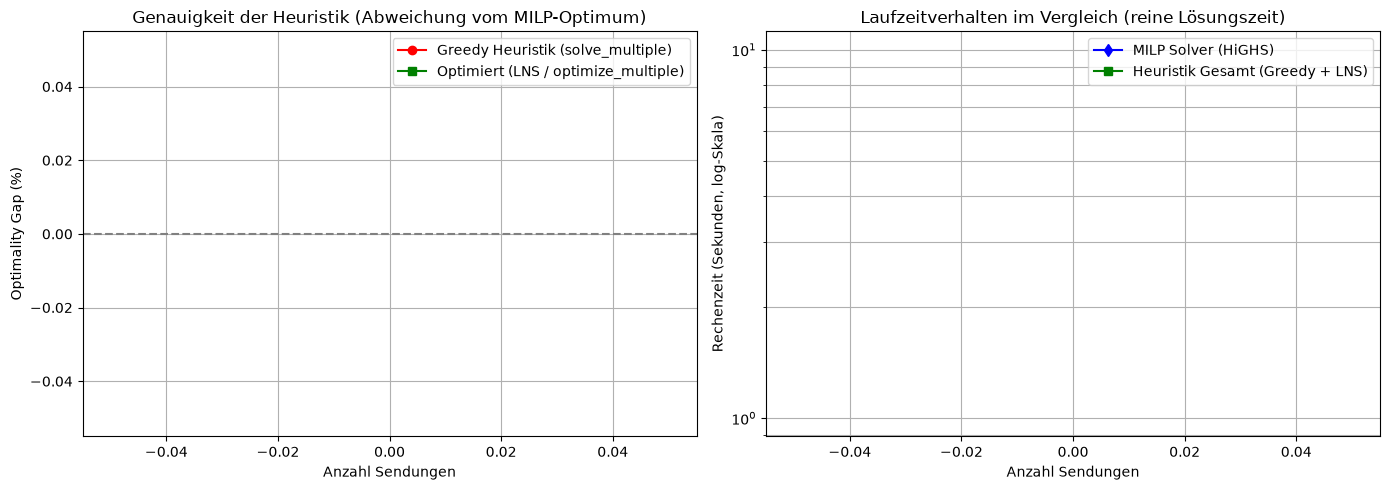

In [ ]:
# Systematischer Benchmark und Plotting
import random
import time
import matplotlib.pyplot as plt

# Parameter
shipment_sizes = [1, 2, 4, 6, 8, 10, 12, 15]
results = {
    "size": [],
    "milp_obj": [],
    "milp_time": [],
    "greedy_obj": [],
    "greedy_time": [],
    "opt_obj": [],
    "opt_time": [],
}

# Medium Netzwerk laden (Relativer Pfad aus dem notebooks-Ordner)
medium_network_data = NetworkDataLoader.from_json("../dataset/medium_network.json")
weights_medium = ObjectiveWeights(cost=0.4, emissions=0.4, time=0.2)
hubs_list = list(medium_network_data.hubs.keys())

random.seed(42)

for size in shipment_sizes:
    # Generiere zufällige Sendungen
    shipments = []
    for i in range(size):
        start = random.choice(hubs_list)
        dest = random.choice(hubs_list)
        while dest == start:
            dest = random.choice(hubs_list)
        shipments.append(
            Shipment(
                id=f"bench_s_{i}",
                start_hub=start,
                end_hub=dest,
                start_time=0,
                deadline=2880,
                max_price=1000000.0,
                max_emissions=None,
                weight=float(random.randint(1, 10)),
            )
        )

    # Zeitunabhängiger Graphenaufbau
    shared_network = TimeExpandedNetwork.build(
        medium_network_data, planning_days=20, shipments=shipments
    )
    shared_model = TimeExpandedFreightRoutingModel(objective_weights=weights_medium)

    # 1. Löse MILP (reine Lösungszeit)
    t0 = time.time()
    res_milp = shared_model.solve(network=shared_network)
    t_milp = time.time() - t0

    # Falls die Instanz für das MILP unzulässig ist, brechen wir den Vergleich ab
    if res_milp.status != "Optimal":
        print(
            f"Abbruch bei {size} Sendungen: MILP nicht optimal (Status: {res_milp.status})"
        )
        break

    # 2. Löse Heuristik mit dem vorbereiteten Netzwerk (reine Lösungszeit)
    router = DijkstraRouter(weights_medium)

    # Greedy (solve_multiple mit übergebenem Netzwerk)
    t0 = time.time()
    res_greedy = router.solve_multiple(network=shared_network)
    t_greedy = time.time() - t0

    # LNS Optimierung (optimize_multiple mit übergebenem Netzwerk)
    t0 = time.time()
    res_opt = router.optimize_multiple(
        res_greedy, network=shared_network, iterations=40, ruin_fraction=0.15, seed=42
    )
    t_opt = time.time() - t0

    # Ergebnisse aufzeichnen
    results["size"].append(size)
    results["milp_obj"].append(res_milp.objective_value)
    results["milp_time"].append(t_milp)
    results["greedy_obj"].append(res_greedy.objective_value)
    results["greedy_time"].append(t_greedy)
    results["opt_obj"].append(res_opt.objective_value)
    results["opt_time"].append(t_greedy + t_opt)

    print(f"[Erfolg] {size} Sendung(en) getestet.")

# Plotten der Ergebnisse
sizes = results["size"]
greedy_gaps = [
    (g - m) / m * 100 for g, m in zip(results["greedy_obj"], results["milp_obj"])
]
opt_gaps = [(o - m) / m * 100 for o, m in zip(results["opt_obj"], results["milp_obj"])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimality Gap
ax1.plot(
    sizes, greedy_gaps, "o-", color="red", label="Greedy Heuristik (solve_multiple)"
)
ax1.plot(
    sizes, opt_gaps, "s-", color="green", label="Optimiert (LNS / optimize_multiple)"
)
ax1.axhline(0, color="gray", linestyle="--")
ax1.set_xlabel("Anzahl Sendungen")
ax1.set_ylabel("Optimality Gap (%)")
ax1.set_title("Genauigkeit der Heuristik (Abweichung vom MILP-Optimum)")
ax1.grid(True)
ax1.legend()

# Plot 2: Rechenzeiten
ax2.plot(sizes, results["milp_time"], "d-", color="blue", label="MILP Solver (HiGHS)")
ax2.plot(
    sizes,
    results["opt_time"],
    "s-",
    color="green",
    label="Heuristik Gesamt (Greedy + LNS)",
)
ax2.set_yscale("log")
ax2.set_xlabel("Anzahl Sendungen")
ax2.set_ylabel("Rechenzeit (Sekunden, log-Skala)")
ax2.set_title("Laufzeitverhalten im Vergleich (reine Lösungszeit)")
ax2.grid(True, which="both", ls="-")
ax2.legend()

plt.tight_layout()
plt.show()